# Local support and sequential reliability calibration — revised

This notebook replaces the first reliability implementation. The revision addresses two empirical problems found in the initial run:

1. the raw local count grew mechanically as the historical sample accumulated;
2. a reliability model fitted once on calibration data did not adapt to the later increase in forecast loss.

The revised procedure uses:

- **dual support:** price familiarity using all historical pricing states and using the matching pricing state;
- **normalized support as the primary statistic:** local kernel weight divided by the relevant historical sample size;
- **past-only recent-error features:** rolling product-level and market-level forecast-loss summaries;
- **prequential reliability estimation:** reliability models are repeatedly refitted using only errors observed before the forecast week;
- **online upper-quantile correction:** recent past residuals adjust the predicted 90th-percentile risk without using current-week outcomes.

The frozen point-demand model remains `product_promotion`. Reliability characteristics do not enter that demand model.

## 1. Imports and configuration

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Any
import gc
import json
import sys
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from scipy.stats import spearmanr
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_pinball_loss
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore", category=FutureWarning)

CURRENT_DIR = Path.cwd().resolve()
POSSIBLE_ROOTS = [CURRENT_DIR, CURRENT_DIR.parent]

PROJECT_ROOT = next(
    (
        root
        for root in POSSIBLE_ROOTS
        if (root / "data" / "processed").is_dir()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Could not locate the project root from {CURRENT_DIR}"
    )

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
TABLE_DIR = PROJECT_ROOT / "results" / "tables"
FIGURE_DIR = PROJECT_ROOT / "results" / "figures"
MODEL_DIR = PROJECT_ROOT / "results" / "models"

for directory in [
    PROCESSED_DIR,
    TABLE_DIR,
    FIGURE_DIR,
    MODEL_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

DATA_PATH = (
    PROCESSED_DIR
    / "cereal_demand_model_data.pkl"
)
PREDICTION_PATH = (
    PROCESSED_DIR
    / "final_demand_model_predictions.pkl"
)

MAIN_DEMAND_MODEL = "product_promotion"
OUTCOME_COLUMN = "poisson_deviance"

# Support configuration.
BANDWIDTH_GRID = np.array(
    [0.02, 0.04, 0.06, 0.08, 0.10],
    dtype=float,
)
EXCLUDE_IMPUTED_HISTORY = True
EXCLUDE_IMPUTED_TARGETS = True
NO_HISTORY_DISTANCE = 1.0

# Recent forecast-loss features.
RECENT_ERROR_LOOKBACK_WEEKS = 26
MIN_PRODUCT_RECENT_OBSERVATIONS = 20
MIN_STATE_RECENT_OBSERVATIONS = 30

# Reliability calibration.
RELIABILITY_QUANTILE = 0.90
RELIABILITY_SEED_SHARE = 0.60
RELIABILITY_REFIT_EVERY_N_WEEKS = 4
CORRECTION_LOOKBACK_WEEKS = 26
MIN_STATE_CORRECTION_OBSERVATIONS = 40
MIN_GLOBAL_CORRECTION_OBSERVATIONS = 100
RANDOM_STATE = 42

print("Project root:", PROJECT_ROOT)
print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("Demand data:", DATA_PATH)
print("Predictions:", PREDICTION_PATH)

Project root: C:\Users\janza\price-of-extrapolation
Python: 3.13.3
pandas: 3.0.3
scikit-learn: 1.9.0
Demand data: C:\Users\janza\price-of-extrapolation\data\processed\cereal_demand_model_data.pkl
Predictions: C:\Users\janza\price-of-extrapolation\data\processed\final_demand_model_predictions.pkl


## 2. Load rolling predictions from the frozen demand model

In [2]:
if not DATA_PATH.is_file():
    raise FileNotFoundError(f"Demand data not found: {DATA_PATH}")

if not PREDICTION_PATH.is_file():
    raise FileNotFoundError(
        "Rolling predictions were not found. Run the saving cell in "
        "03_demand_model_final_selection.ipynb first:\n"
        f"{PREDICTION_PATH}"
    )

predictions_all = pd.read_pickle(PREDICTION_PATH)

required_prediction_columns = {
    "store",
    "upc",
    "store_upc",
    "week",
    "move",
    "mu_hat",
    "model",
    "split",
    "model_unit_price",
    "unit_price_observed",
    "regular_price",
    "discount_depth_model",
    "price_imputed",
    "pricing_state",
    "promotion_indicator",
    "post_promotion_indicator",
    "reference_price",
    "poisson_deviance",
}

missing_prediction_columns = (
    required_prediction_columns
    .difference(predictions_all.columns)
)

if missing_prediction_columns:
    raise ValueError(
        "Missing prediction columns: "
        f"{sorted(missing_prediction_columns)}"
    )

targets = predictions_all[
    predictions_all["model"].astype(str)
    == MAIN_DEMAND_MODEL
].copy()

if targets.empty:
    available_models = sorted(
        predictions_all["model"]
        .astype(str)
        .unique()
        .tolist()
    )
    raise ValueError(
        f"Model {MAIN_DEMAND_MODEL!r} not found. "
        f"Available models: {available_models}"
    )

for column in ["store", "upc", "store_upc"]:
    targets[column] = targets[column].astype(str)

targets["week"] = pd.to_numeric(
    targets["week"],
    errors="coerce",
)
targets["price_imputed"] = (
    targets["price_imputed"]
    .fillna(False)
    .astype(bool)
)
targets["promotion_indicator"] = (
    targets["promotion_indicator"]
    .fillna(0)
    .astype(int)
)
targets["post_promotion_indicator"] = (
    targets["post_promotion_indicator"]
    .fillna(0)
    .astype(int)
)

for column in [
    "model_unit_price",
    "reference_price",
    "regular_price",
    "discount_depth_model",
    "mu_hat",
    OUTCOME_COLUMN,
]:
    targets[column] = pd.to_numeric(
        targets[column],
        errors="coerce",
    )

valid_targets = (
    targets["week"].notna()
    & targets["model_unit_price"].notna()
    & np.isfinite(targets["model_unit_price"])
    & (targets["model_unit_price"] > 0)
    & targets["mu_hat"].notna()
    & np.isfinite(targets["mu_hat"])
    & (targets["mu_hat"] > 0)
    & targets[OUTCOME_COLUMN].notna()
    & np.isfinite(targets[OUTCOME_COLUMN])
)

targets = targets.loc[valid_targets].copy()
targets["week"] = targets["week"].astype(int)

if EXCLUDE_IMPUTED_TARGETS:
    rows_before = len(targets)
    targets = targets.loc[
        ~targets["price_imputed"]
    ].copy()
    print(
        "Excluded imputed target-price observations:",
        f"{rows_before - len(targets):,}",
    )

targets["support_state"] = np.select(
    [
        targets["promotion_indicator"].eq(1),
        targets["post_promotion_indicator"].eq(1),
    ],
    [
        "promotion",
        "post_promotion",
    ],
    default="regular",
)

targets["log_price"] = np.log(
    targets["model_unit_price"]
)

valid_reference = (
    targets["reference_price"].notna()
    & np.isfinite(targets["reference_price"])
    & (targets["reference_price"] > 0)
)

targets["reference_price_distance"] = 0.0
targets.loc[
    valid_reference,
    "reference_price_distance",
] = np.abs(
    np.log(
        targets.loc[
            valid_reference,
            "model_unit_price",
        ]
        / targets.loc[
            valid_reference,
            "reference_price",
        ]
    )
)

targets["discount_depth_model"] = (
    targets["discount_depth_model"]
    .fillna(0.0)
    .clip(lower=0.0, upper=0.95)
)
targets["log1p_mu_hat"] = np.log1p(
    targets["mu_hat"]
)

targets = targets.sort_values(
    ["store_upc", "week"]
).reset_index(drop=True)

duplicate_targets = targets.duplicated(
    ["store_upc", "week"]
).sum()

if duplicate_targets:
    raise ValueError(
        f"Found {duplicate_targets} duplicate target panel-weeks."
    )

print(f"Frozen demand model: {MAIN_DEMAND_MODEL}")
print(f"Target observations: {len(targets):,}")

display(
    targets.groupby(
        ["split", "support_state"],
        observed=True,
    )
    .agg(
        observations=("move", "size"),
        mean_loss=(OUTCOME_COLUMN, "mean"),
        q90_loss=(
            OUTCOME_COLUMN,
            lambda x: x.quantile(0.90),
        ),
    )
    .reset_index()
)

Excluded imputed target-price observations: 247
Frozen demand model: product_promotion
Target observations: 16,791


,split,support_state,observations,mean_loss,q90_loss
0,calibration,post_promotion,460,7.679925,19.352594
1,calibration,promotion,1089,109.219054,240.789199
2,calibration,regular,6654,6.359293,16.022038
3,test,post_promotion,637,18.976828,28.120369
4,test,promotion,1147,220.310694,387.317143
5,test,regular,6804,12.251445,17.305618


## 3. Load observed historical prices for the selected panels

In [3]:
history_columns = [
    "store",
    "upc",
    "store_upc",
    "week",
    "model_unit_price",
    "unit_price_observed",
    "price_imputed",
    "pricing_state",
    "sales_outlier",
]

history_raw = pd.read_pickle(DATA_PATH)

missing_history_columns = (
    set(history_columns)
    .difference(history_raw.columns)
)

if missing_history_columns:
    raise ValueError(
        "Missing historical columns: "
        f"{sorted(missing_history_columns)}"
    )

history = history_raw[history_columns].copy()
del history_raw
gc.collect()

for column in ["store", "upc", "store_upc"]:
    history[column] = history[column].astype(str)

history["week"] = pd.to_numeric(
    history["week"],
    errors="coerce",
)
history["model_unit_price"] = pd.to_numeric(
    history["model_unit_price"],
    errors="coerce",
)
history["price_imputed"] = (
    history["price_imputed"]
    .fillna(False)
    .astype(bool)
)
history["sales_outlier"] = (
    history["sales_outlier"]
    .fillna(False)
    .astype(bool)
)

selected_panels = set(
    targets["store_upc"].unique()
)
history = history[
    history["store_upc"].isin(selected_panels)
].copy()

state_normalized = (
    history["pricing_state"]
    .astype("string")
    .fillna("unknown")
    .str.strip()
    .str.lower()
    .str.replace("_", " ", regex=False)
    .str.replace("-", " ", regex=False)
)

history["post_promotion_indicator"] = (
    state_normalized.str.contains(
        "post",
        na=False,
    )
).astype(int)

history["promotion_indicator"] = (
    state_normalized.str.contains(
        "promo",
        na=False,
    )
    & ~state_normalized.str.contains(
        "post",
        na=False,
    )
).astype(int)

history["support_state"] = np.select(
    [
        history["promotion_indicator"].eq(1),
        history["post_promotion_indicator"].eq(1),
    ],
    [
        "promotion",
        "post_promotion",
    ],
    default="regular",
)

valid_history = (
    history["week"].notna()
    & history["model_unit_price"].notna()
    & np.isfinite(history["model_unit_price"])
    & (history["model_unit_price"] > 0)
    & ~history["sales_outlier"]
    & history["unit_price_observed"].notna()
)

if EXCLUDE_IMPUTED_HISTORY:
    valid_history &= ~history["price_imputed"]

history = history.loc[valid_history].copy()
history["week"] = history["week"].astype(int)
history["log_price"] = np.log(
    history["model_unit_price"]
)

history = history.sort_values(
    ["store_upc", "week"]
).reset_index(drop=True)

duplicate_history = history.duplicated(
    ["store_upc", "week"]
).sum()

if duplicate_history:
    raise ValueError(
        f"Found {duplicate_history} duplicate historical panel-weeks."
    )

print(f"Observed historical price rows: {len(history):,}")
print(f"Historical panels: {history['store_upc'].nunique()}")

Observed historical price rows: 42,480
Historical panels: 120


## 4. Strictly past-looking dual support

For each target price \(p_t\), two support statistics are constructed.

All-state support:

\[
N^{\mathrm{all}}_t(p_t)
=
\sum_{j<t}
\exp\left[
-\frac{1}{2}
\left(
\frac{\log p_j-\log p_t}{h}
\right)^2
\right].
\]

State-matched support restricts the same sum to the matching regular, promotion, or post-promotion state.

The primary versions divide the kernel counts by the relevant historical sample sizes:

\[
S^{\mathrm{all}}_t
=
\frac{N^{\mathrm{all}}_t}{H^{\mathrm{all}}_t},
\qquad
S^{\mathrm{state}}_t
=
\frac{N^{\mathrm{state}}_t}{H^{\mathrm{state}}_t}.
\]

These normalized statistics measure the share of historical observations located near the target price and do not increase mechanically merely because more weeks have elapsed.

In [4]:
def bandwidth_suffix(
    bandwidth: float,
) -> str:
    return f"{bandwidth:.2f}".replace(".", "p")


def _scope_geometry(
    eligible_mask: np.ndarray,
    price_distance: np.ndarray,
    history_log_price: np.ndarray,
    target_log_price: np.ndarray,
) -> dict[str, np.ndarray]:
    n_targets = eligible_mask.shape[0]
    history_size = eligible_mask.sum(axis=1)

    masked_distance = np.where(
        eligible_mask,
        price_distance,
        np.inf,
    )
    nearest_distance = masked_distance.min(axis=1)
    nearest_distance[
        ~np.isfinite(nearest_distance)
    ] = NO_HISTORY_DISTANCE

    historical_min = np.full(
        n_targets,
        np.nan,
        dtype=float,
    )
    historical_max = np.full(
        n_targets,
        np.nan,
        dtype=float,
    )

    for row_index in np.flatnonzero(
        history_size > 0
    ):
        available_prices = history_log_price[
            eligible_mask[row_index]
        ]
        historical_min[row_index] = (
            available_prices.min()
        )
        historical_max[row_index] = (
            available_prices.max()
        )

    no_history = history_size == 0
    below_range = (
        ~no_history
        & (target_log_price < historical_min)
    )
    above_range = (
        ~no_history
        & (target_log_price > historical_max)
    )

    outside_range = (
        no_history
        | below_range
        | above_range
    )

    outside_distance = np.zeros(
        n_targets,
        dtype=float,
    )
    outside_distance[below_range] = (
        historical_min[below_range]
        - target_log_price[below_range]
    )
    outside_distance[above_range] = (
        target_log_price[above_range]
        - historical_max[above_range]
    )
    outside_distance[no_history] = (
        NO_HISTORY_DISTANCE
    )

    return {
        "history_size": history_size,
        "nearest_distance": nearest_distance,
        "outside_range": (
            outside_range.astype(int)
        ),
        "outside_distance": outside_distance,
        "no_history": no_history.astype(int),
    }


def compute_dual_support_grid(
    target_frame: pd.DataFrame,
    history_frame: pd.DataFrame,
    bandwidths: np.ndarray,
) -> pd.DataFrame:
    """
    Compute all-state and state-matched support using only history
    from weeks strictly before each target week.
    """
    bandwidths = np.asarray(
        bandwidths,
        dtype=float,
    )

    if np.any(~np.isfinite(bandwidths)):
        raise ValueError("Bandwidths must be finite.")
    if np.any(bandwidths <= 0):
        raise ValueError("Bandwidths must be positive.")

    history_groups = {
        panel: group.sort_values("week")
        for panel, group in history_frame.groupby(
            "store_upc",
            observed=True,
            sort=False,
        )
    }

    blocks = []

    for panel, target_panel in target_frame.groupby(
        "store_upc",
        observed=True,
        sort=False,
    ):
        target_panel = target_panel.sort_values(
            "week"
        ).copy()
        history_panel = history_groups.get(panel)

        if history_panel is None or history_panel.empty:
            block = target_panel.copy()

            for scope in ["all", "state"]:
                block[
                    f"history_size_{scope}"
                ] = 0
                block[
                    f"nearest_price_distance_{scope}"
                ] = NO_HISTORY_DISTANCE
                block[
                    f"outside_historical_range_{scope}"
                ] = 1
                block[
                    f"outside_range_distance_{scope}"
                ] = NO_HISTORY_DISTANCE
                block[
                    f"no_history_{scope}"
                ] = 1

                for bandwidth in bandwidths:
                    suffix = bandwidth_suffix(
                        bandwidth
                    )
                    block[
                        f"local_support_{scope}_h_{suffix}"
                    ] = 0.0
                    block[
                        f"normalized_support_{scope}_h_{suffix}"
                    ] = 0.0

            blocks.append(block)
            continue

        target_week = target_panel[
            "week"
        ].to_numpy(dtype=int)
        target_log_price = target_panel[
            "log_price"
        ].to_numpy(dtype=float)
        target_state = target_panel[
            "support_state"
        ].astype(str).to_numpy()

        history_week = history_panel[
            "week"
        ].to_numpy(dtype=int)
        history_log_price = history_panel[
            "log_price"
        ].to_numpy(dtype=float)
        history_state = history_panel[
            "support_state"
        ].astype(str).to_numpy()

        past_mask = (
            history_week[None, :]
            < target_week[:, None]
        )
        state_mask = (
            history_state[None, :]
            == target_state[:, None]
        )

        eligible_masks = {
            "all": past_mask,
            "state": past_mask & state_mask,
        }

        price_distance = np.abs(
            target_log_price[:, None]
            - history_log_price[None, :]
        )

        block = target_panel.copy()

        for scope, eligible_mask in (
            eligible_masks.items()
        ):
            geometry = _scope_geometry(
                eligible_mask=eligible_mask,
                price_distance=price_distance,
                history_log_price=(
                    history_log_price
                ),
                target_log_price=(
                    target_log_price
                ),
            )

            block[
                f"history_size_{scope}"
            ] = geometry["history_size"]
            block[
                f"nearest_price_distance_{scope}"
            ] = geometry["nearest_distance"]
            block[
                f"outside_historical_range_{scope}"
            ] = geometry["outside_range"]
            block[
                f"outside_range_distance_{scope}"
            ] = geometry["outside_distance"]
            block[
                f"no_history_{scope}"
            ] = geometry["no_history"]

            for bandwidth in bandwidths:
                kernel_weights = np.exp(
                    -0.5
                    * (
                        price_distance
                        / bandwidth
                    ) ** 2
                )
                kernel_weights = np.where(
                    eligible_mask,
                    kernel_weights,
                    0.0,
                )

                local_support = (
                    kernel_weights.sum(axis=1)
                )
                normalized_support = np.divide(
                    local_support,
                    geometry["history_size"],
                    out=np.zeros_like(
                        local_support,
                        dtype=float,
                    ),
                    where=(
                        geometry["history_size"]
                        > 0
                    ),
                )

                suffix = bandwidth_suffix(
                    bandwidth
                )
                block[
                    f"local_support_{scope}_h_{suffix}"
                ] = local_support
                block[
                    f"normalized_support_{scope}_h_{suffix}"
                ] = normalized_support

        blocks.append(block)

    output = pd.concat(
        blocks,
        ignore_index=True,
    )

    return output.sort_values(
        ["store_upc", "week"]
    ).reset_index(drop=True)


support_data = compute_dual_support_grid(
    target_frame=targets,
    history_frame=history,
    bandwidths=BANDWIDTH_GRID,
)

print(f"Support rows: {len(support_data):,}")

display(
    support_data.groupby(
        ["split", "support_state"],
        observed=True,
    )
    .agg(
        observations=("move", "size"),
        mean_history_all=(
            "history_size_all",
            "mean",
        ),
        mean_history_state=(
            "history_size_state",
            "mean",
        ),
        outside_all_share=(
            "outside_historical_range_all",
            "mean",
        ),
        outside_state_share=(
            "outside_historical_range_state",
            "mean",
        ),
    )
    .reset_index()
)

Support rows: 16,791


,split,support_state,observations,mean_history_all,mean_history_state,outside_all_share,outside_state_share
0,calibration,post_promotion,460,245.445652,15.910870,0.008696,0.271739
1,calibration,promotion,1089,239.785124,32.669421,0.066116,0.167126
2,calibration,regular,6654,246.388638,205.906522,0.029757,0.029907
3,test,post_promotion,637,311.207221,19.932496,0.001570,0.097331
4,test,promotion,1147,313.276373,43.167393,0.052310,0.087184
5,test,regular,6804,318.328630,263.594650,0.009553,0.009847


## 5. Past-only recent forecast-loss features

For each forecast week, recent-error features use only rolling demand-forecast losses observed in earlier weeks. They are computed over the preceding 26 weeks.

The features include:

- promotion-specific overall mean and 90th-percentile loss;
- product-by-promotion mean and 90th-percentile loss;
- the numbers of past observations supporting those summaries.

Sparse product-level summaries fall back to the corresponding promotion-specific overall summaries. These variables allow the reliability score to increase when the demand model has recently become less accurate.

In [5]:
def add_past_only_recent_error_features(
    frame: pd.DataFrame,
    lookback_weeks: int,
    min_product_observations: int,
    min_state_observations: int,
) -> pd.DataFrame:
    frame = frame.sort_values(
        ["week", "store_upc"]
    ).copy()

    blocks = []

    for current_week in np.sort(
        frame["week"].unique()
    ):
        current = frame[
            frame["week"] == current_week
        ].copy()

        recent = frame[
            (frame["week"] < current_week)
            & (
                frame["week"]
                >= current_week - lookback_weeks
            )
        ].copy()

        if recent.empty:
            current[
                "recent_global_mean_loss"
            ] = 0.0
            current[
                "recent_global_q90_loss"
            ] = 0.0
            current[
                "recent_global_count"
            ] = 0
            current[
                "recent_product_mean_loss"
            ] = 0.0
            current[
                "recent_product_q90_loss"
            ] = 0.0
            current[
                "recent_product_count"
            ] = 0
            current[
                "recent_error_history_available"
            ] = 0
            blocks.append(current)
            continue

        overall_mean = float(
            recent[OUTCOME_COLUMN].mean()
        )
        overall_q90 = float(
            recent[OUTCOME_COLUMN].quantile(
                RELIABILITY_QUANTILE
            )
        )
        overall_count = int(len(recent))

        state_stats = (
            recent.groupby(
                "promotion_indicator",
                observed=True,
            )
            .agg(
                state_mean=(OUTCOME_COLUMN, "mean"),
                state_q90=(
                    OUTCOME_COLUMN,
                    lambda x: x.quantile(
                        RELIABILITY_QUANTILE
                    ),
                ),
                state_count=(OUTCOME_COLUMN, "size"),
            )
        )

        product_stats = (
            recent.groupby(
                ["upc", "promotion_indicator"],
                observed=True,
            )
            .agg(
                product_mean=(
                    OUTCOME_COLUMN,
                    "mean",
                ),
                product_q90=(
                    OUTCOME_COLUMN,
                    lambda x: x.quantile(
                        RELIABILITY_QUANTILE
                    ),
                ),
                product_count=(
                    OUTCOME_COLUMN,
                    "size",
                ),
            )
        )

        global_means = []
        global_q90s = []
        global_counts = []
        product_means = []
        product_q90s = []
        product_counts = []

        for row in current[
            ["upc", "promotion_indicator"]
        ].itertuples(index=False):
            state = int(
                row.promotion_indicator
            )
            product_key = (
                str(row.upc),
                state,
            )

            if state in state_stats.index:
                state_row = state_stats.loc[state]
                state_count = int(
                    state_row["state_count"]
                )
            else:
                state_row = None
                state_count = 0

            if (
                state_row is not None
                and state_count
                >= min_state_observations
            ):
                global_mean = float(
                    state_row["state_mean"]
                )
                global_q90 = float(
                    state_row["state_q90"]
                )
                global_count = state_count
            else:
                global_mean = overall_mean
                global_q90 = overall_q90
                global_count = overall_count

            if product_key in product_stats.index:
                product_row = product_stats.loc[
                    product_key
                ]
                product_count = int(
                    product_row[
                        "product_count"
                    ]
                )
            else:
                product_row = None
                product_count = 0

            if (
                product_row is not None
                and product_count
                >= min_product_observations
            ):
                product_mean = float(
                    product_row["product_mean"]
                )
                product_q90 = float(
                    product_row["product_q90"]
                )
            else:
                product_mean = global_mean
                product_q90 = global_q90

            global_means.append(global_mean)
            global_q90s.append(global_q90)
            global_counts.append(global_count)
            product_means.append(product_mean)
            product_q90s.append(product_q90)
            product_counts.append(product_count)

        current[
            "recent_global_mean_loss"
        ] = global_means
        current[
            "recent_global_q90_loss"
        ] = global_q90s
        current[
            "recent_global_count"
        ] = global_counts
        current[
            "recent_product_mean_loss"
        ] = product_means
        current[
            "recent_product_q90_loss"
        ] = product_q90s
        current[
            "recent_product_count"
        ] = product_counts
        current[
            "recent_error_history_available"
        ] = 1

        blocks.append(current)

    output = pd.concat(
        blocks,
        ignore_index=True,
    )

    for source, destination in [
        (
            "recent_global_mean_loss",
            "log1p_recent_global_mean_loss",
        ),
        (
            "recent_global_q90_loss",
            "log1p_recent_global_q90_loss",
        ),
        (
            "recent_product_mean_loss",
            "log1p_recent_product_mean_loss",
        ),
        (
            "recent_product_q90_loss",
            "log1p_recent_product_q90_loss",
        ),
        (
            "recent_global_count",
            "log1p_recent_global_count",
        ),
        (
            "recent_product_count",
            "log1p_recent_product_count",
        ),
    ]:
        output[destination] = np.log1p(
            output[source]
        )

    return output.sort_values(
        ["store_upc", "week"]
    ).reset_index(drop=True)


support_data = add_past_only_recent_error_features(
    frame=support_data,
    lookback_weeks=RECENT_ERROR_LOOKBACK_WEEKS,
    min_product_observations=(
        MIN_PRODUCT_RECENT_OBSERVATIONS
    ),
    min_state_observations=(
        MIN_STATE_RECENT_OBSERVATIONS
    ),
)

display(
    support_data.groupby(
        ["split", "promotion_indicator"],
        observed=True,
    )
    .agg(
        observations=("move", "size"),
        mean_recent_q90=(
            "recent_global_q90_loss",
            "mean",
        ),
        mean_product_recent_q90=(
            "recent_product_q90_loss",
            "mean",
        ),
        recent_history_share=(
            "recent_error_history_available",
            "mean",
        ),
    )
    .reset_index()
)

,split,promotion_indicator,observations,mean_recent_q90,mean_product_recent_q90,recent_history_share
0,calibration,0,7114,15.748394,15.326217,0.968513
1,calibration,1,1089,224.137133,260.454936,0.985308
2,test,0,7441,16.314754,16.133551,1.000000
3,test,1,1147,316.664111,393.691110,1.000000


## 6. Bandwidth-specific reliability features

In [6]:
def add_bandwidth_features(
    frame: pd.DataFrame,
    bandwidth: float,
) -> pd.DataFrame:
    output = frame.copy()
    suffix = bandwidth_suffix(bandwidth)

    for scope in ["all", "state"]:
        local_column = (
            f"local_support_{scope}_h_{suffix}"
        )
        normalized_column = (
            f"normalized_support_{scope}_h_{suffix}"
        )

        if local_column not in output.columns:
            raise KeyError(local_column)
        if normalized_column not in output.columns:
            raise KeyError(normalized_column)

        output[
            f"local_support_{scope}"
        ] = output[local_column]
        output[
            f"normalized_support_{scope}"
        ] = output[normalized_column]
        output[
            f"log1p_local_support_{scope}"
        ] = np.log1p(
            output[f"local_support_{scope}"]
        )
        output[
            f"log1p_history_size_{scope}"
        ] = np.log1p(
            output[f"history_size_{scope}"]
        )

    output["support_state_minus_all"] = (
        output["normalized_support_state"]
        - output["normalized_support_all"]
    )

    return output


SUPPORT_FEATURES = [
    # Primary time-stable support statistics.
    "normalized_support_all",
    "normalized_support_state",
    "support_state_minus_all",
    # Secondary precision and geometry statistics.
    "log1p_local_support_all",
    "log1p_local_support_state",
    "log1p_history_size_all",
    "log1p_history_size_state",
    "nearest_price_distance_all",
    "nearest_price_distance_state",
    "outside_historical_range_all",
    "outside_historical_range_state",
    "outside_range_distance_all",
    "outside_range_distance_state",
    "no_history_all",
    "no_history_state",
]

RECENT_ERROR_FEATURES = [
    "log1p_recent_global_mean_loss",
    "log1p_recent_global_q90_loss",
    "log1p_recent_product_mean_loss",
    "log1p_recent_product_q90_loss",
    "log1p_recent_global_count",
    "log1p_recent_product_count",
    "recent_error_history_available",
]

CONTEXT_FEATURES = [
    "discount_depth_model",
    "reference_price_distance",
    "log1p_mu_hat",
    "post_promotion_indicator",
]

FULL_FEATURES = (
    SUPPORT_FEATURES
    + RECENT_ERROR_FEATURES
    + CONTEXT_FEATURES
)

RECENT_ONLY_FEATURES = (
    RECENT_ERROR_FEATURES
    + CONTEXT_FEATURES
)

SUPPORT_ONLY_FEATURES = (
    SUPPORT_FEATURES
    + CONTEXT_FEATURES
)

CATEGORICAL_FEATURES = ["upc"]

## 7. Reliability-model and evaluation utilities

In [7]:
def make_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=False,
        )


def make_quantile_pipeline(
    numeric_features: list[str],
) -> Pipeline:
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                "passthrough",
                numeric_features,
            ),
            (
                "categorical",
                make_one_hot_encoder(),
                CATEGORICAL_FEATURES,
            ),
        ],
        remainder="drop",
        sparse_threshold=0.0,
    )

    regressor = GradientBoostingRegressor(
        loss="quantile",
        alpha=RELIABILITY_QUANTILE,
        n_estimators=150,
        learning_rate=0.04,
        max_depth=2,
        min_samples_leaf=40,
        random_state=RANDOM_STATE,
    )

    return Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("regressor", regressor),
        ]
    )


@dataclass
class StratifiedQuantileModel:
    pipelines: dict[int, Pipeline | None]
    fallback_quantiles: dict[int, float]
    numeric_features: list[str]


def fit_stratified_quantile_model(
    frame: pd.DataFrame,
    numeric_features: list[str],
) -> StratifiedQuantileModel:
    pipelines: dict[int, Pipeline | None] = {}
    fallback_quantiles: dict[int, float] = {}

    overall_fallback = float(
        frame[OUTCOME_COLUMN].quantile(
            RELIABILITY_QUANTILE
        )
    )

    for promotion_state in [0, 1]:
        subset = frame[
            frame["promotion_indicator"]
            == promotion_state
        ].copy()

        if subset.empty:
            pipelines[promotion_state] = None
            fallback_quantiles[
                promotion_state
            ] = overall_fallback
            continue

        state_fallback = float(
            subset[OUTCOME_COLUMN].quantile(
                RELIABILITY_QUANTILE
            )
        )
        fallback_quantiles[
            promotion_state
        ] = state_fallback

        if len(subset) < 150:
            pipelines[promotion_state] = None
            continue

        feature_columns = (
            numeric_features
            + CATEGORICAL_FEATURES
        )

        pipeline = make_quantile_pipeline(
            numeric_features
        )
        pipeline.fit(
            subset[feature_columns],
            subset[OUTCOME_COLUMN],
        )
        pipelines[promotion_state] = pipeline

    return StratifiedQuantileModel(
        pipelines=pipelines,
        fallback_quantiles=(
            fallback_quantiles
        ),
        numeric_features=numeric_features,
    )


def predict_stratified_quantile_model(
    model: StratifiedQuantileModel,
    frame: pd.DataFrame,
) -> np.ndarray:
    prediction = np.full(
        len(frame),
        np.nan,
        dtype=float,
    )

    promotion = frame[
        "promotion_indicator"
    ].to_numpy(dtype=int)

    for promotion_state in [0, 1]:
        mask = promotion == promotion_state

        if not mask.any():
            continue

        pipeline = model.pipelines[
            promotion_state
        ]

        if pipeline is None:
            prediction[mask] = (
                model.fallback_quantiles[
                    promotion_state
                ]
            )
        else:
            prediction[mask] = pipeline.predict(
                frame.loc[
                    mask,
                    (
                        model.numeric_features
                        + CATEGORICAL_FEATURES
                    ),
                ]
            )

    if np.any(~np.isfinite(prediction)):
        raise ValueError(
            "Reliability predictions contain non-finite values."
        )

    return np.clip(prediction, 0.0, None)


def empirical_upper_quantile(
    values: np.ndarray,
    quantile: float,
) -> float:
    values = np.asarray(
        values,
        dtype=float,
    )
    values = values[
        np.isfinite(values)
    ]

    if len(values) == 0:
        return 0.0

    try:
        return float(
            np.quantile(
                values,
                quantile,
                method="higher",
            )
        )
    except TypeError:
        return float(
            np.quantile(
                values,
                quantile,
                interpolation="higher",
            )
        )


def recent_residual_correction(
    residual_history: pd.DataFrame,
    promotion_state: int,
    current_week: int,
) -> tuple[float, int, str]:
    recent = residual_history[
        (residual_history["week"] < current_week)
        & (
            residual_history["week"]
            >= current_week
            - CORRECTION_LOOKBACK_WEEKS
        )
    ]

    state_recent = recent[
        recent["promotion_indicator"]
        == promotion_state
    ]

    if (
        len(state_recent)
        >= MIN_STATE_CORRECTION_OBSERVATIONS
    ):
        residuals = state_recent[
            "raw_residual"
        ].to_numpy(dtype=float)
        source = "state"
    elif (
        len(recent)
        >= MIN_GLOBAL_CORRECTION_OBSERVATIONS
    ):
        residuals = recent[
            "raw_residual"
        ].to_numpy(dtype=float)
        source = "global"
    else:
        return 0.0, int(len(state_recent)), "none"

    correction = empirical_upper_quantile(
        residuals,
        RELIABILITY_QUANTILE,
    )

    # The reliability screen is one-sided. The online correction
    # may increase risk but does not reduce the model's raw risk.
    correction = max(0.0, correction)

    return correction, int(len(residuals)), source


def reliability_metrics(
    observed: np.ndarray,
    predicted_risk: np.ndarray,
) -> dict[str, float]:
    observed = np.asarray(
        observed,
        dtype=float,
    )
    predicted_risk = np.asarray(
        predicted_risk,
        dtype=float,
    )

    exceedance = observed > predicted_risk

    return {
        "n": int(len(observed)),
        "pinball_loss": float(
            mean_pinball_loss(
                observed,
                predicted_risk,
                alpha=RELIABILITY_QUANTILE,
            )
        ),
        "coverage": float(
            np.mean(~exceedance)
        ),
        "coverage_gap": float(
            np.mean(~exceedance)
            - RELIABILITY_QUANTILE
        ),
        "mean_predicted_risk": float(
            predicted_risk.mean()
        ),
        "median_predicted_risk": float(
            np.median(predicted_risk)
        ),
        "exceedance_rate": float(
            exceedance.mean()
        ),
        "mean_positive_exceedance": float(
            np.maximum(
                observed - predicted_risk,
                0.0,
            ).mean()
        ),
    }


def assert_finite_features(
    frame: pd.DataFrame,
    numeric_features: list[str],
) -> None:
    feature_values = frame[
        numeric_features
    ].to_numpy(dtype=float)

    if np.any(~np.isfinite(feature_values)):
        bad_columns = [
            column
            for column in numeric_features
            if not np.isfinite(
                frame[column].to_numpy(
                    dtype=float
                )
            ).all()
        ]
        raise ValueError(
            "Non-finite reliability features: "
            f"{bad_columns}"
        )

## 8. Prequential reliability forecasting

For an evaluation week \(t\):

1. the reliability model is fitted using only forecast losses from weeks strictly before \(t\);
2. raw 90th-percentile risk is predicted for week \(t\);
3. a nonnegative correction is estimated from recent past raw residuals;
4. week-\(t\) outcomes are observed only after its risk forecasts are stored;
5. those outcomes become available for subsequent weeks.

The model itself is refitted every four weeks for computational efficiency. Recent-error features and residual corrections still update every week.

In [8]:
def prequential_reliability_forecast(
    frame: pd.DataFrame,
    evaluation_weeks: np.ndarray,
    numeric_features: list[str],
    model_name: str,
    refit_every_n_weeks: int,
    correction_seed: pd.DataFrame | None = None,
) -> pd.DataFrame:
    evaluation_weeks = np.asarray(
        sorted(evaluation_weeks),
        dtype=int,
    )

    if correction_seed is None:
        residual_history = pd.DataFrame(
            columns=[
                "week",
                "promotion_indicator",
                "raw_residual",
            ]
        )
    else:
        residual_history = correction_seed[
            [
                "week",
                "promotion_indicator",
                "raw_residual",
            ]
        ].copy()

    output_blocks = []

    for block_start in range(
        0,
        len(evaluation_weeks),
        refit_every_n_weeks,
    ):
        block_weeks = evaluation_weeks[
            block_start:
            block_start + refit_every_n_weeks
        ]
        first_week = int(block_weeks[0])

        fit_data = frame[
            frame["week"] < first_week
        ].copy()

        if fit_data.empty:
            raise ValueError(
                f"No reliability training data before week {first_week}."
            )

        assert_finite_features(
            fit_data,
            numeric_features,
        )

        fitted_model = (
            fit_stratified_quantile_model(
                frame=fit_data,
                numeric_features=numeric_features,
            )
        )

        for current_week in block_weeks:
            current = frame[
                frame["week"] == current_week
            ].copy()

            if current.empty:
                continue

            assert_finite_features(
                current,
                numeric_features,
            )

            raw_risk = (
                predict_stratified_quantile_model(
                    fitted_model,
                    current,
                )
            )

            promotion = current[
                "promotion_indicator"
            ].to_numpy(dtype=int)

            corrections = np.zeros(
                len(current),
                dtype=float,
            )
            correction_counts = np.zeros(
                len(current),
                dtype=int,
            )
            correction_sources = np.empty(
                len(current),
                dtype=object,
            )

            for promotion_state in [0, 1]:
                mask = (
                    promotion == promotion_state
                )

                if not mask.any():
                    continue

                (
                    correction,
                    correction_count,
                    correction_source,
                ) = recent_residual_correction(
                    residual_history=(
                        residual_history
                    ),
                    promotion_state=(
                        promotion_state
                    ),
                    current_week=int(
                        current_week
                    ),
                )

                corrections[mask] = correction
                correction_counts[
                    mask
                ] = correction_count
                correction_sources[
                    mask
                ] = correction_source

            corrected_risk = np.clip(
                raw_risk + corrections,
                0.0,
                None,
            )

            current[
                "reliability_model"
            ] = model_name
            current["risk_raw"] = raw_risk
            current["risk"] = corrected_risk
            current[
                "online_correction"
            ] = corrections
            current[
                "correction_observations"
            ] = correction_counts
            current[
                "correction_source"
            ] = correction_sources
            current[
                "reliability_fit_last_week"
            ] = fit_data["week"].max()
            current["raw_residual"] = (
                current[OUTCOME_COLUMN]
                - current["risk_raw"]
            )

            output_blocks.append(current)

            # Outcomes from the current week become available only
            # after all current-week risk forecasts are stored.
            new_residuals = current[
                [
                    "week",
                    "promotion_indicator",
                    "raw_residual",
                ]
            ].copy()

            residual_history = pd.concat(
                [
                    residual_history,
                    new_residuals,
                ],
                ignore_index=True,
            )

    if not output_blocks:
        raise RuntimeError(
            f"No prequential predictions generated for {model_name}."
        )

    return pd.concat(
        output_blocks,
        ignore_index=True,
    ).sort_values(
        ["week", "store_upc"]
    ).reset_index(drop=True)


def prequential_constant_quantile(
    frame: pd.DataFrame,
    evaluation_weeks: np.ndarray,
) -> pd.DataFrame:
    blocks = []

    for current_week in np.asarray(
        sorted(evaluation_weeks),
        dtype=int,
    ):
        fit_data = frame[
            frame["week"] < current_week
        ]
        current = frame[
            frame["week"] == current_week
        ].copy()

        overall_quantile = float(
            fit_data[OUTCOME_COLUMN].quantile(
                RELIABILITY_QUANTILE
            )
        )

        state_quantiles = (
            fit_data.groupby(
                "promotion_indicator",
                observed=True,
            )[OUTCOME_COLUMN]
            .quantile(RELIABILITY_QUANTILE)
            .to_dict()
        )

        current["risk"] = (
            current["promotion_indicator"]
            .map(state_quantiles)
            .fillna(overall_quantile)
            .astype(float)
        )
        current["risk_raw"] = current["risk"]
        current[
            "online_correction"
        ] = 0.0
        current[
            "reliability_model"
        ] = "constant_by_promotion"
        current["raw_residual"] = (
            current[OUTCOME_COLUMN]
            - current["risk_raw"]
        )
        blocks.append(current)

    return pd.concat(
        blocks,
        ignore_index=True,
    )


def recent_q90_baseline(
    frame: pd.DataFrame,
    evaluation_weeks: np.ndarray,
) -> pd.DataFrame:
    output = frame[
        frame["week"].isin(
            evaluation_weeks
        )
    ].copy()

    output["risk"] = output[
        "recent_global_q90_loss"
    ].clip(lower=0.0)
    output["risk_raw"] = output["risk"]
    output["online_correction"] = 0.0
    output[
        "reliability_model"
    ] = "recent_q90_by_promotion"
    output["raw_residual"] = (
        output[OUTCOME_COLUMN]
        - output["risk_raw"]
    )

    return output

## 9. Chronological calibration seed and validation periods

In [9]:
calibration_data = support_data[
    support_data["split"] == "calibration"
].copy()

test_data = support_data[
    support_data["split"] == "test"
].copy()

calibration_weeks = np.sort(
    calibration_data["week"].unique()
)
test_weeks = np.sort(
    test_data["week"].unique()
)

seed_end_index = int(
    np.floor(
        RELIABILITY_SEED_SHARE
        * len(calibration_weeks)
    )
)

seed_weeks = calibration_weeks[
    :seed_end_index
]
validation_weeks = calibration_weeks[
    seed_end_index:
]

if len(seed_weeks) == 0:
    raise ValueError(
        "The reliability seed period is empty."
    )
if len(validation_weeks) == 0:
    raise ValueError(
        "The reliability validation period is empty."
    )

print(
    "Reliability seed:",
    seed_weeks[0],
    "to",
    seed_weeks[-1],
    f"({len(seed_weeks)} weeks)",
)
print(
    "Reliability validation:",
    validation_weeks[0],
    "to",
    validation_weeks[-1],
    f"({len(validation_weeks)} weeks)",
)
print(
    "Sequential test:",
    test_weeks[0],
    "to",
    test_weeks[-1],
    f"({len(test_weeks)} weeks)",
)

Reliability seed: 223 to 269 (42 weeks)
Reliability validation: 270 to 324 (28 weeks)
Sequential test: 325 to 399 (72 weeks)


## 10. Select the support bandwidth using prequential calibration only

In [10]:
bandwidth_rows = []
bandwidth_validation_outputs = {}

for bandwidth in BANDWIDTH_GRID:
    calibration_h = add_bandwidth_features(
        calibration_data,
        bandwidth,
    )

    validation_output = (
        prequential_reliability_forecast(
            frame=calibration_h,
            evaluation_weeks=validation_weeks,
            numeric_features=FULL_FEATURES,
            model_name="full_reliability",
            refit_every_n_weeks=(
                RELIABILITY_REFIT_EVERY_N_WEEKS
            ),
            correction_seed=None,
        )
    )

    bandwidth_validation_outputs[
        float(bandwidth)
    ] = validation_output

    raw_metrics = reliability_metrics(
        observed=validation_output[
            OUTCOME_COLUMN
        ].to_numpy(dtype=float),
        predicted_risk=validation_output[
            "risk_raw"
        ].to_numpy(dtype=float),
    )
    corrected_metrics = reliability_metrics(
        observed=validation_output[
            OUTCOME_COLUMN
        ].to_numpy(dtype=float),
        predicted_risk=validation_output[
            "risk"
        ].to_numpy(dtype=float),
    )

    bandwidth_rows.append(
        {
            "bandwidth": float(bandwidth),
            "risk_version": "raw",
            **raw_metrics,
        }
    )
    bandwidth_rows.append(
        {
            "bandwidth": float(bandwidth),
            "risk_version": "online_corrected",
            **corrected_metrics,
        }
    )

bandwidth_results = pd.DataFrame(
    bandwidth_rows
)

bandwidth_ranking = (
    bandwidth_results[
        bandwidth_results[
            "risk_version"
        ] == "online_corrected"
    ]
    .sort_values(
        ["pinball_loss", "bandwidth"]
    )
    .reset_index(drop=True)
)

SELECTED_BANDWIDTH = float(
    bandwidth_ranking.loc[
        0,
        "bandwidth",
    ]
)

print(
    "Selected bandwidth:",
    SELECTED_BANDWIDTH,
)
display(
    bandwidth_results.sort_values(
        ["risk_version", "pinball_loss"]
    )
)

Selected bandwidth: 0.06


,bandwidth,risk_version,n,pinball_loss,coverage,coverage_gap,mean_predicted_risk,median_predicted_risk,exceedance_rate,mean_positive_exceedance
5,0.06,online_corrected,3197,5.706526,0.899906,-0.000094,43.271104,14.784574,0.100094,2.917445
3,0.04,online_corrected,3197,5.725112,0.901470,0.001470,42.995434,14.433275,0.098530,2.963599
1,0.02,online_corrected,3197,5.731332,0.897091,-0.002909,42.425912,14.460177,0.102909,3.026771
9,0.10,online_corrected,3197,5.832525,0.901157,0.001157,43.454420,14.729921,0.098843,3.025113
7,0.08,online_corrected,3197,5.840002,0.905224,0.005224,44.555721,14.942588,0.094776,2.922460
4,0.06,raw,3197,5.279234,0.887394,-0.012606,35.107601,13.721502,0.112606,3.306504
0,0.02,raw,3197,5.289421,0.883641,-0.016359,33.393667,13.281788,0.116359,3.488085
2,0.04,raw,3197,5.306253,0.887707,-0.012293,34.744377,13.320511,0.112293,3.369846
8,0.10,raw,3197,5.377500,0.885830,-0.014170,34.399104,13.623652,0.114170,3.475620
6,0.08,raw,3197,5.382509,0.891774,-0.008226,35.755379,13.760484,0.108226,3.345002


## 11. Plot calibration-only bandwidth selection

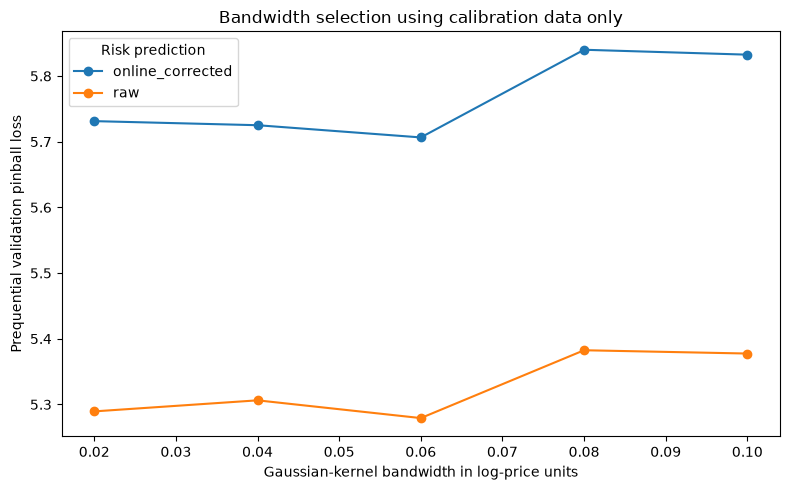

Saved: C:\Users\janza\price-of-extrapolation\results\figures\reliability_bandwidth_selection_revised.png


In [11]:
bandwidth_plot = (
    bandwidth_results.pivot(
        index="bandwidth",
        columns="risk_version",
        values="pinball_loss",
    )
    .sort_index()
)

fig, ax = plt.subplots(figsize=(8, 5))
bandwidth_plot.plot(
    marker="o",
    ax=ax,
)

ax.set_xlabel(
    "Gaussian-kernel bandwidth in log-price units"
)
ax.set_ylabel(
    "Prequential validation pinball loss"
)
ax.set_title(
    "Bandwidth selection using calibration data only"
)
ax.legend(title="Risk prediction")

fig.tight_layout()

bandwidth_figure_path = (
    FIGURE_DIR
    / "reliability_bandwidth_selection_revised.png"
)
fig.savefig(
    bandwidth_figure_path,
    dpi=200,
    bbox_inches="tight",
)
plt.show()

print("Saved:", bandwidth_figure_path)

## 12. Validation ablations at the selected bandwidth

The ablation comparison separates the information contributed by support from the information contributed by recent forecast performance.

- `support_only`: dual support and candidate geometry;
- `recent_only`: recent loss and candidate context;
- `full_reliability`: support, recent loss, and candidate context;
- `constant_by_promotion`: expanding historical 90th percentile by promotion status;
- `recent_q90_by_promotion`: direct rolling-loss benchmark.

The key comparison is `full_reliability` versus `recent_only`. The full model must improve risk ordering or pinball loss for local support to have incremental empirical value.

In [12]:
support_selected = add_bandwidth_features(
    support_data,
    SELECTED_BANDWIDTH,
)
calibration_selected = support_selected[
    support_selected["split"]
    == "calibration"
].copy()
test_selected = support_selected[
    support_selected["split"]
    == "test"
].copy()

validation_outputs = {}

# Reuse the already generated selected-bandwidth full output.
validation_outputs[
    "full_reliability"
] = bandwidth_validation_outputs[
    SELECTED_BANDWIDTH
]

validation_outputs[
    "support_only"
] = prequential_reliability_forecast(
    frame=calibration_selected,
    evaluation_weeks=validation_weeks,
    numeric_features=SUPPORT_ONLY_FEATURES,
    model_name="support_only",
    refit_every_n_weeks=(
        RELIABILITY_REFIT_EVERY_N_WEEKS
    ),
)

validation_outputs[
    "recent_only"
] = prequential_reliability_forecast(
    frame=calibration_selected,
    evaluation_weeks=validation_weeks,
    numeric_features=RECENT_ONLY_FEATURES,
    model_name="recent_only",
    refit_every_n_weeks=(
        RELIABILITY_REFIT_EVERY_N_WEEKS
    ),
)

validation_outputs[
    "constant_by_promotion"
] = prequential_constant_quantile(
    frame=calibration_selected,
    evaluation_weeks=validation_weeks,
)

validation_outputs[
    "recent_q90_by_promotion"
] = recent_q90_baseline(
    frame=calibration_selected,
    evaluation_weeks=validation_weeks,
)

## 13. Sequential test evaluation

In [13]:
all_selected = pd.concat(
    [
        calibration_selected,
        test_selected,
    ],
    ignore_index=True,
).sort_values(
    ["week", "store_upc"]
)

feature_sets = {
    "full_reliability": FULL_FEATURES,
    "support_only": SUPPORT_ONLY_FEATURES,
    "recent_only": RECENT_ONLY_FEATURES,
}

test_outputs = {}

for model_name, numeric_features in (
    feature_sets.items()
):
    correction_seed = (
        validation_outputs[model_name][
            [
                "week",
                "promotion_indicator",
                "raw_residual",
            ]
        ]
        .copy()
    )

    test_outputs[
        model_name
    ] = prequential_reliability_forecast(
        frame=all_selected,
        evaluation_weeks=test_weeks,
        numeric_features=numeric_features,
        model_name=model_name,
        refit_every_n_weeks=(
            RELIABILITY_REFIT_EVERY_N_WEEKS
        ),
        correction_seed=correction_seed,
    )

test_outputs[
    "constant_by_promotion"
] = prequential_constant_quantile(
    frame=all_selected,
    evaluation_weeks=test_weeks,
)

test_outputs[
    "recent_q90_by_promotion"
] = recent_q90_baseline(
    frame=all_selected,
    evaluation_weeks=test_weeks,
)

print("Sequential test predictions completed.")

Sequential test predictions completed.


## 14. Reliability metrics

In [14]:
def metric_rows(
    output: pd.DataFrame,
    split_name: str,
    model_name: str,
) -> list[dict[str, Any]]:
    rows = []

    risk_columns = ["risk"]

    if model_name in feature_sets:
        risk_columns = [
            "risk_raw",
            "risk",
        ]

    for risk_column in risk_columns:
        risk_version = (
            "raw"
            if risk_column == "risk_raw"
            else "online_corrected"
        )

        for promotion_state in [
            "all",
            0,
            1,
        ]:
            if promotion_state == "all":
                subset = output
            else:
                subset = output[
                    output[
                        "promotion_indicator"
                    ] == promotion_state
                ]

            metrics = reliability_metrics(
                observed=subset[
                    OUTCOME_COLUMN
                ].to_numpy(dtype=float),
                predicted_risk=subset[
                    risk_column
                ].to_numpy(dtype=float),
            )

            rows.append(
                {
                    "split": split_name,
                    "model": model_name,
                    "risk_version": risk_version,
                    "promotion_indicator": (
                        promotion_state
                    ),
                    **metrics,
                }
            )

    return rows


evaluation_rows = []

for split_name, outputs in [
    ("validation", validation_outputs),
    ("test", test_outputs),
]:
    for model_name, output in outputs.items():
        evaluation_rows.extend(
            metric_rows(
                output=output,
                split_name=split_name,
                model_name=model_name,
            )
        )

reliability_evaluation = pd.DataFrame(
    evaluation_rows
)

display(
    reliability_evaluation.sort_values(
        [
            "split",
            "promotion_indicator",
            "pinball_loss",
        ]
    )
)

,split,model,risk_version,promotion_indicator,n,pinball_loss,coverage,coverage_gap,mean_predicted_risk,median_predicted_risk,exceedance_rate,mean_positive_exceedance
28,test,full_reliability,online_corrected,0,7441,7.854735,0.891144,-0.008856,17.004814,15.660007,0.108856,7.436972
40,test,recent_only,online_corrected,0,7441,7.857815,0.892622,-0.007378,16.906684,15.175841,0.107378,7.449865
37,test,recent_only,raw,0,7441,7.861400,0.884559,-0.015441,16.185305,14.423128,0.115441,7.525588
25,test,full_reliability,raw,0,7441,7.862051,0.882677,-0.017323,16.102964,14.484505,0.117323,7.534473
34,test,support_only,online_corrected,0,7441,7.893239,0.893294,-0.006706,17.738921,16.747210,0.106706,7.402065
31,test,support_only,raw,0,7441,7.900175,0.880124,-0.019876,16.349987,15.343757,0.119876,7.547895
43,test,constant_by_promotion,online_corrected,0,7441,8.021863,0.888993,-0.011007,16.834627,16.822012,0.111007,7.621119
46,test,recent_q90_by_promotion,online_corrected,0,7441,8.076541,0.878511,-0.021489,16.314754,15.850749,0.121489,7.727784
44,test,constant_by_promotion,online_corrected,1,1147,125.633252,0.858762,-0.041238,262.159959,263.155085,0.141238,121.448325
47,test,recent_q90_by_promotion,online_corrected,1,1147,126.673580,0.870968,-0.029032,316.664111,297.588385,0.129032,117.038238


## 15. Incremental value of local support

In [15]:
overall_corrected = (
    reliability_evaluation[
        (
            reliability_evaluation[
                "promotion_indicator"
            ] == "all"
        )
        & (
            reliability_evaluation[
                "risk_version"
            ] == "online_corrected"
        )
    ]
    .pivot(
        index="split",
        columns="model",
        values=[
            "pinball_loss",
            "coverage",
        ],
    )
)

display(overall_corrected)

for split_name in ["validation", "test"]:
    split_metrics = reliability_evaluation[
        (
            reliability_evaluation["split"]
            == split_name
        )
        & (
            reliability_evaluation[
                "promotion_indicator"
            ] == "all"
        )
        & (
            reliability_evaluation[
                "risk_version"
            ] == "online_corrected"
        )
        & (
            reliability_evaluation["model"]
            .isin(
                [
                    "full_reliability",
                    "recent_only",
                ]
            )
        )
    ].set_index("model")

    if {
        "full_reliability",
        "recent_only",
    }.issubset(split_metrics.index):
        recent_loss = float(
            split_metrics.loc[
                "recent_only",
                "pinball_loss",
            ]
        )
        full_loss = float(
            split_metrics.loc[
                "full_reliability",
                "pinball_loss",
            ]
        )

        relative_change = (
            full_loss / recent_loss - 1.0
        )

        print(
            f"{split_name}: full versus recent-only "
            f"pinball-loss change = "
            f"{relative_change:.2%}"
        )

pinball_loss                               \
model      constant_by_promotion full_reliability recent_only   
split                                                           
test                   23.729858        25.514127   23.908316   
validation              5.689182         5.706526    5.681500   

                                                             coverage  \
model      recent_q90_by_promotion support_only constant_by_promotion   
split                                                                   
test                     23.916178     25.24048              0.884956   
validation                7.385323      5.40286              0.911792   

                                                                              
model      full_reliability recent_only recent_q90_by_promotion support_only  
split                                                                         
test               0.889963    0.892059                0.877503     0.891127  
validation         0.899906    0.906475                0.859869     0.900219

validation: full versus recent-only pinball-loss change = 0.44%
test: full versus recent-only pinball-loss change = 6.72%


## 16. Forecast loss by normalized support

Support-group cutoffs are estimated on the full calibration sample separately for promotion and non-promotion observations. The same cutoffs are then applied unchanged to test observations.

The primary grouping variable is **state-matched normalized support**. Group 1 is the weakest support and group 5 is the strongest whenever five distinct groups are available.

In [16]:
def fit_support_group_edges(
    frame: pd.DataFrame,
    value_column: str,
    n_groups: int = 5,
) -> dict[int, np.ndarray]:
    edges = {}

    for promotion_state in [0, 1]:
        values = (
            frame.loc[
                frame["promotion_indicator"]
                == promotion_state,
                value_column,
            ]
            .dropna()
            .to_numpy(dtype=float)
        )

        state_edges = np.unique(
            np.quantile(
                values,
                np.linspace(
                    0.0,
                    1.0,
                    n_groups + 1,
                ),
            )
        )

        if len(state_edges) < 3:
            raise ValueError(
                "Insufficient normalized-support variation for "
                f"promotion state {promotion_state}."
            )

        state_edges[0] = -np.inf
        state_edges[-1] = np.inf
        edges[promotion_state] = state_edges

    return edges


def apply_support_groups(
    frame: pd.DataFrame,
    edges: dict[int, np.ndarray],
    value_column: str,
) -> pd.Series:
    output = pd.Series(
        pd.NA,
        index=frame.index,
        dtype="Int64",
    )

    for promotion_state, state_edges in (
        edges.items()
    ):
        mask = (
            frame["promotion_indicator"]
            == promotion_state
        )
        labels = np.arange(
            1,
            len(state_edges),
        )

        output.loc[mask] = pd.cut(
            frame.loc[
                mask,
                value_column,
            ],
            bins=state_edges,
            labels=labels,
            include_lowest=True,
        ).astype("Int64")

    return output


PRIMARY_SUPPORT_COLUMN = (
    "normalized_support_state"
)

support_group_edges = (
    fit_support_group_edges(
        frame=calibration_selected,
        value_column=PRIMARY_SUPPORT_COLUMN,
    )
)

calibration_selected[
    "support_group"
] = apply_support_groups(
    frame=calibration_selected,
    edges=support_group_edges,
    value_column=PRIMARY_SUPPORT_COLUMN,
)

test_selected[
    "support_group"
] = apply_support_groups(
    frame=test_selected,
    edges=support_group_edges,
    value_column=PRIMARY_SUPPORT_COLUMN,
)

support_group_data = pd.concat(
    [
        calibration_selected,
        test_selected,
    ],
    ignore_index=True,
)

support_loss_table = (
    support_group_data.groupby(
        [
            "split",
            "promotion_indicator",
            "support_group",
        ],
        observed=True,
    )
    .agg(
        n=(OUTCOME_COLUMN, "size"),
        mean_normalized_support_state=(
            "normalized_support_state",
            "mean",
        ),
        mean_normalized_support_all=(
            "normalized_support_all",
            "mean",
        ),
        mean_raw_support_state=(
            "local_support_state",
            "mean",
        ),
        mean_loss=(OUTCOME_COLUMN, "mean"),
        median_loss=(
            OUTCOME_COLUMN,
            "median",
        ),
        q90_loss=(
            OUTCOME_COLUMN,
            lambda x: x.quantile(0.90),
        ),
    )
    .reset_index()
)

display(support_loss_table)

,split,promotion_indicator,support_group,n,mean_normalized_support_state,mean_normalized_support_all,mean_raw_support_state,mean_loss,median_loss,q90_loss
0,calibration,0,1,1423,0.076985,0.074289,13.869312,5.958495,2.234145,14.468664
1,calibration,0,2,1423,0.152173,0.141430,30.539945,7.212046,2.561704,15.531845
2,calibration,0,3,1422,0.232758,0.218061,50.095372,5.038899,2.132526,12.936951
3,calibration,0,4,1423,0.392948,0.381145,78.122322,6.665967,2.633326,17.685964
4,calibration,0,5,1423,0.628399,0.599876,110.697306,7.347038,3.172535,19.549080
5,calibration,1,1,218,0.018877,0.027954,0.666575,98.801027,36.493270,268.379432
6,calibration,1,2,218,0.063138,0.045228,2.083794,154.682735,66.743482,435.114434
7,calibration,1,3,217,0.164791,0.176355,4.864534,137.292170,55.004963,390.161211
8,calibration,1,4,218,0.405966,0.453971,13.492832,69.006118,54.298433,149.139807
9,calibration,1,5,218,0.568224,0.521085,19.411757,86.441994,69.327963,169.036214


## 17. Normalized-support distribution stability

In [17]:
support_distribution = (
    support_group_data.groupby(
        [
            "split",
            "promotion_indicator",
            "support_group",
        ],
        observed=True,
    )
    .size()
    .rename("n")
    .reset_index()
)

support_distribution["share_within_state"] = (
    support_distribution.groupby(
        ["split", "promotion_indicator"],
        observed=True,
    )["n"]
    .transform(
        lambda x: x / x.sum()
    )
)

display(support_distribution)

,split,promotion_indicator,support_group,n,share_within_state
0,calibration,0,1,1423,0.200028
1,calibration,0,2,1423,0.200028
2,calibration,0,3,1422,0.199888
3,calibration,0,4,1423,0.200028
4,calibration,0,5,1423,0.200028
5,calibration,1,1,218,0.200184
6,calibration,1,2,218,0.200184
7,calibration,1,3,217,0.199265
8,calibration,1,4,218,0.200184
9,calibration,1,5,218,0.200184


## 18. Support–loss rank correlations

In [18]:
correlation_rows = []

for split_name, frame in [
    ("calibration", calibration_selected),
    ("test", test_selected),
]:
    for promotion_state in [0, 1]:
        subset = frame[
            frame["promotion_indicator"]
            == promotion_state
        ]

        for support_column in [
            "normalized_support_state",
            "normalized_support_all",
            "local_support_state",
            "local_support_all",
        ]:
            correlation, p_value = spearmanr(
                subset[support_column],
                subset[OUTCOME_COLUMN],
                nan_policy="omit",
            )

            correlation_rows.append(
                {
                    "split": split_name,
                    "promotion_indicator": (
                        promotion_state
                    ),
                    "support_measure": (
                        support_column
                    ),
                    "n": len(subset),
                    "spearman_support_loss": (
                        correlation
                    ),
                    "p_value": p_value,
                }
            )

support_correlations = pd.DataFrame(
    correlation_rows
)

display(support_correlations)

,split,promotion_indicator,support_measure,n,spearman_support_loss,p_value
0,calibration,0,normalized_support_state,7114,0.047528,6.063874e-05
1,calibration,0,normalized_support_all,7114,0.050386,2.121513e-05
2,calibration,0,local_support_state,7114,0.020125,8.964498e-02
3,calibration,0,local_support_all,7114,0.043533,2.398320e-04
4,calibration,1,normalized_support_state,1089,0.082030,6.759604e-03
5,calibration,1,normalized_support_all,1089,-0.007963,7.929600e-01
6,calibration,1,local_support_state,1089,0.113050,1.852231e-04
7,calibration,1,local_support_all,1089,-0.008338,7.834364e-01
8,test,0,normalized_support_state,7441,-0.054337,2.734238e-06
9,test,0,normalized_support_all,7441,-0.047463,4.206741e-05


## 19. Plot upper-tail loss by normalized-support group

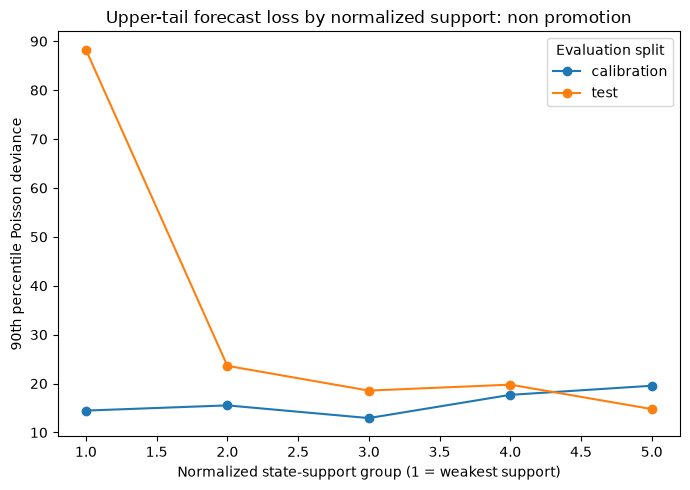

Saved: C:\Users\janza\price-of-extrapolation\results\figures\normalized_support_loss_q90_non_promotion.png


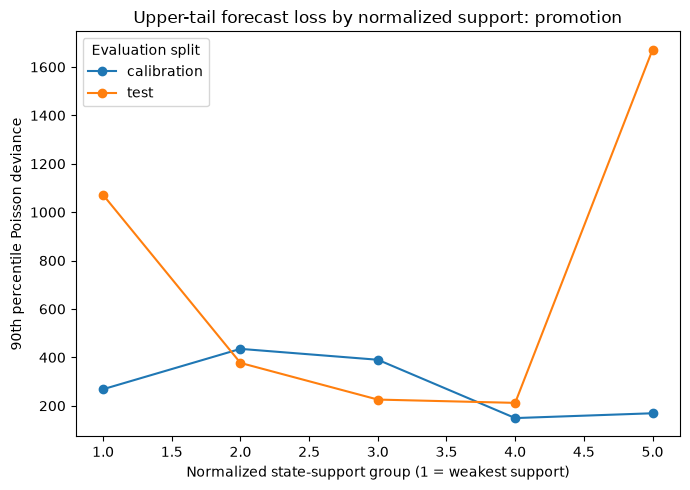

Saved: C:\Users\janza\price-of-extrapolation\results\figures\normalized_support_loss_q90_promotion.png


In [19]:
for promotion_state, state_label in [
    (0, "non_promotion"),
    (1, "promotion"),
]:
    plot_data = support_loss_table[
        support_loss_table[
            "promotion_indicator"
        ] == promotion_state
    ].copy()

    pivot = plot_data.pivot(
        index="support_group",
        columns="split",
        values="q90_loss",
    ).sort_index()

    fig, ax = plt.subplots(figsize=(7, 5))
    pivot.plot(
        marker="o",
        ax=ax,
    )

    ax.set_xlabel(
        "Normalized state-support group "
        "(1 = weakest support)"
    )
    ax.set_ylabel(
        "90th percentile Poisson deviance"
    )
    ax.set_title(
        "Upper-tail forecast loss by normalized support: "
        f"{state_label.replace('_', ' ')}"
    )
    ax.legend(title="Evaluation split")

    fig.tight_layout()

    figure_path = (
        FIGURE_DIR
        / (
            "normalized_support_loss_q90_"
            f"{state_label}.png"
        )
    )
    fig.savefig(
        figure_path,
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

    print("Saved:", figure_path)

## 20. Test-period calibration by predicted-risk decile

In [20]:
full_test_output = test_outputs[
    "full_reliability"
].copy()

risk_decile_blocks = []

for promotion_state in [0, 1]:
    subset = full_test_output[
        full_test_output[
            "promotion_indicator"
        ] == promotion_state
    ].copy()

    subset["risk_decile"] = pd.qcut(
        subset["risk"],
        q=10,
        labels=False,
        duplicates="drop",
    ) + 1

    block = (
        subset.groupby(
            "risk_decile",
            observed=True,
        )
        .apply(
            lambda group: pd.Series(
                {
                    "n": len(group),
                    "mean_predicted_risk": (
                        group["risk"].mean()
                    ),
                    "empirical_q90_loss": (
                        group[OUTCOME_COLUMN]
                        .quantile(
                            RELIABILITY_QUANTILE
                        )
                    ),
                    "coverage": np.mean(
                        group[OUTCOME_COLUMN]
                        <= group["risk"]
                    ),
                }
            )
        )
        .reset_index()
    )

    block[
        "promotion_indicator"
    ] = promotion_state
    risk_decile_blocks.append(block)

risk_deciles = pd.concat(
    risk_decile_blocks,
    ignore_index=True,
)

display(risk_deciles)

,risk_decile,n,mean_predicted_risk,empirical_q90_loss,coverage,promotion_indicator
0,1,747.0,9.390425,13.256917,0.840696,0
1,2,743.0,11.465949,14.668295,0.864065,0
2,3,743.0,12.675832,14.285787,0.872140,0
3,4,744.0,14.038986,12.189760,0.920699,0
4,5,744.0,15.177048,17.061315,0.877688,0
5,6,745.0,16.275320,13.527413,0.920805,0
6,7,743.0,17.579829,16.461042,0.903096,0
7,8,747.0,19.546120,19.707545,0.898260,0
8,9,742.0,22.945995,19.811106,0.920485,0
9,10,743.0,30.996361,33.969933,0.893674,0


## 21. Plot test-period reliability calibration

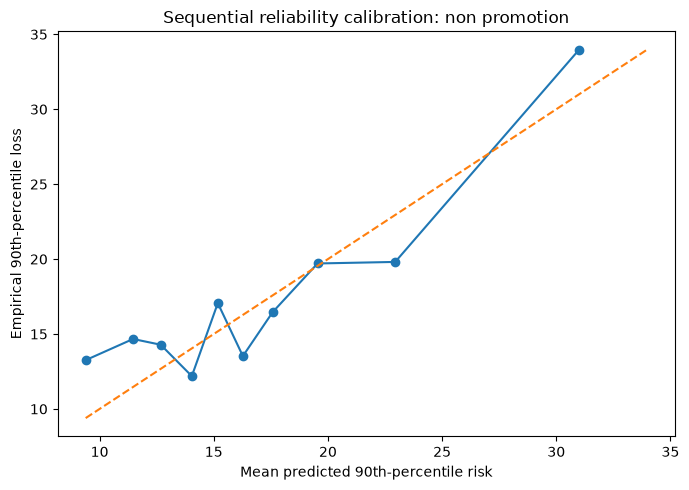

Saved: C:\Users\janza\price-of-extrapolation\results\figures\sequential_reliability_calibration_non_promotion.png


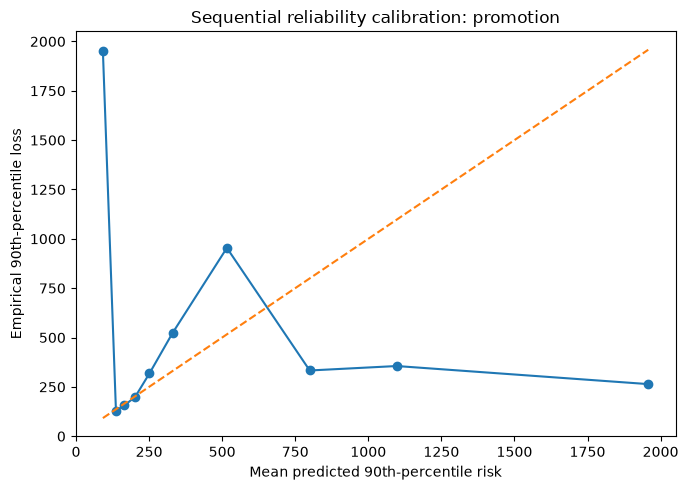

Saved: C:\Users\janza\price-of-extrapolation\results\figures\sequential_reliability_calibration_promotion.png


In [21]:
for promotion_state, state_label in [
    (0, "non_promotion"),
    (1, "promotion"),
]:
    plot_data = risk_deciles[
        risk_deciles[
            "promotion_indicator"
        ] == promotion_state
    ].sort_values("risk_decile")

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(
        plot_data["mean_predicted_risk"],
        plot_data["empirical_q90_loss"],
        marker="o",
    )

    lower = min(
        plot_data[
            "mean_predicted_risk"
        ].min(),
        plot_data[
            "empirical_q90_loss"
        ].min(),
    )
    upper = max(
        plot_data[
            "mean_predicted_risk"
        ].max(),
        plot_data[
            "empirical_q90_loss"
        ].max(),
    )

    ax.plot(
        [lower, upper],
        [lower, upper],
        linestyle="--",
    )

    ax.set_xlabel(
        "Mean predicted 90th-percentile risk"
    )
    ax.set_ylabel(
        "Empirical 90th-percentile loss"
    )
    ax.set_title(
        "Sequential reliability calibration: "
        f"{state_label.replace('_', ' ')}"
    )

    fig.tight_layout()

    figure_path = (
        FIGURE_DIR
        / (
            "sequential_reliability_calibration_"
            f"{state_label}.png"
        )
    )
    fig.savefig(
        figure_path,
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

    print("Saved:", figure_path)

## 22. Candidate-price dual-support helper

The next pricing-policy notebook can use this function for candidate prices. Required candidate columns are:

```text
store_upc, week, candidate_price,
promotion_indicator, post_promotion_indicator
```

The function calculates candidate-specific all-state and state-matched support using only historical prices from earlier weeks.

Recent-error features remain decision-week characteristics. They should be attached using the latest losses observed before the candidate's decision week.

In [22]:
def compute_candidate_dual_support(
    candidates: pd.DataFrame,
    historical_prices: pd.DataFrame,
    bandwidth: float,
) -> pd.DataFrame:
    required_candidate_columns = {
        "store_upc",
        "week",
        "candidate_price",
        "promotion_indicator",
        "post_promotion_indicator",
    }
    required_history_columns = {
        "store_upc",
        "week",
        "log_price",
        "support_state",
    }

    missing_candidates = (
        required_candidate_columns
        .difference(candidates.columns)
    )
    missing_history = (
        required_history_columns
        .difference(historical_prices.columns)
    )

    if missing_candidates:
        raise ValueError(
            "Missing candidate columns: "
            f"{sorted(missing_candidates)}"
        )
    if missing_history:
        raise ValueError(
            "Missing historical columns: "
            f"{sorted(missing_history)}"
        )

    candidate_frame = candidates.copy()

    candidate_frame["candidate_price"] = (
        pd.to_numeric(
            candidate_frame[
                "candidate_price"
            ],
            errors="coerce",
        )
    )

    invalid_candidate = (
        candidate_frame[
            "candidate_price"
        ].isna()
        | ~np.isfinite(
            candidate_frame[
                "candidate_price"
            ]
        )
        | (
            candidate_frame[
                "candidate_price"
            ] <= 0
        )
    )

    if invalid_candidate.any():
        raise ValueError(
            "Candidate prices must be finite and positive."
        )

    candidate_frame[
        "model_unit_price"
    ] = candidate_frame[
        "candidate_price"
    ]
    candidate_frame["log_price"] = np.log(
        candidate_frame[
            "candidate_price"
        ]
    )

    candidate_frame["support_state"] = np.select(
        [
            candidate_frame[
                "promotion_indicator"
            ].eq(1),
            candidate_frame[
                "post_promotion_indicator"
            ].eq(1),
        ],
        [
            "promotion",
            "post_promotion",
        ],
        default="regular",
    )

    candidate_support = compute_dual_support_grid(
        target_frame=candidate_frame,
        history_frame=historical_prices,
        bandwidths=np.array(
            [bandwidth],
            dtype=float,
        ),
    )

    return add_bandwidth_features(
        candidate_support,
        bandwidth,
    )

## 23. Fit a latest deployment model after evaluation

In [23]:
# This model is fitted after the reported sequential evaluation.
# It is an operational artifact for subsequent forward-looking use;
# it is not used to calculate the test results above.

latest_full_model = (
    fit_stratified_quantile_model(
        frame=all_selected,
        numeric_features=FULL_FEATURES,
    )
)

latest_correction_history = (
    full_test_output[
        [
            "week",
            "promotion_indicator",
            "raw_residual",
        ]
    ]
    .copy()
)

latest_model_artifact = {
    "demand_model": MAIN_DEMAND_MODEL,
    "reliability_quantile": (
        RELIABILITY_QUANTILE
    ),
    "selected_bandwidth": (
        SELECTED_BANDWIDTH
    ),
    "numeric_features": FULL_FEATURES,
    "categorical_features": (
        CATEGORICAL_FEATURES
    ),
    "model": latest_full_model,
    "correction_history": (
        latest_correction_history
    ),
    "correction_lookback_weeks": (
        CORRECTION_LOOKBACK_WEEKS
    ),
}

## 24. Save revised outputs

In [24]:
prequential_validation = pd.concat(
    validation_outputs.values(),
    ignore_index=True,
)
prequential_test = pd.concat(
    test_outputs.values(),
    ignore_index=True,
)

prequential_outputs = pd.concat(
    [
        prequential_validation.assign(
            evaluation_split="validation"
        ),
        prequential_test.assign(
            evaluation_split="test"
        ),
    ],
    ignore_index=True,
)

support_output_path = (
    PROCESSED_DIR
    / "local_support_reliability_data_revised.pkl"
)
prequential_output_path = (
    PROCESSED_DIR
    / "reliability_prequential_predictions_revised.pkl"
)
bandwidth_table_path = (
    TABLE_DIR
    / "local_support_bandwidth_selection_revised.csv"
)
evaluation_path = (
    TABLE_DIR
    / "reliability_model_evaluation_revised.csv"
)
support_loss_path = (
    TABLE_DIR
    / "normalized_support_loss_by_group.csv"
)
support_distribution_path = (
    TABLE_DIR
    / "normalized_support_group_distribution.csv"
)
correlation_path = (
    TABLE_DIR
    / "normalized_support_loss_correlations.csv"
)
risk_decile_path = (
    TABLE_DIR
    / "sequential_reliability_risk_deciles.csv"
)
model_artifact_path = (
    MODEL_DIR
    / "reliability_model_latest_revised.joblib"
)
configuration_path = (
    MODEL_DIR
    / "reliability_configuration_revised.json"
)

support_selected.to_pickle(
    support_output_path
)
prequential_outputs.to_pickle(
    prequential_output_path
)
bandwidth_results.to_csv(
    bandwidth_table_path,
    index=False,
)
reliability_evaluation.to_csv(
    evaluation_path,
    index=False,
)
support_loss_table.to_csv(
    support_loss_path,
    index=False,
)
support_distribution.to_csv(
    support_distribution_path,
    index=False,
)
support_correlations.to_csv(
    correlation_path,
    index=False,
)
risk_deciles.to_csv(
    risk_decile_path,
    index=False,
)

joblib.dump(
    latest_model_artifact,
    model_artifact_path,
)

configuration = {
    "demand_model": MAIN_DEMAND_MODEL,
    "selected_bandwidth": (
        SELECTED_BANDWIDTH
    ),
    "bandwidth_grid": (
        BANDWIDTH_GRID.tolist()
    ),
    "reliability_quantile": (
        RELIABILITY_QUANTILE
    ),
    "reliability_seed_share": (
        RELIABILITY_SEED_SHARE
    ),
    "reliability_refit_every_n_weeks": (
        RELIABILITY_REFIT_EVERY_N_WEEKS
    ),
    "recent_error_lookback_weeks": (
        RECENT_ERROR_LOOKBACK_WEEKS
    ),
    "correction_lookback_weeks": (
        CORRECTION_LOOKBACK_WEEKS
    ),
    "exclude_imputed_history": (
        EXCLUDE_IMPUTED_HISTORY
    ),
    "exclude_imputed_targets": (
        EXCLUDE_IMPUTED_TARGETS
    ),
    "primary_support_measure": (
        PRIMARY_SUPPORT_COLUMN
    ),
    "full_features": FULL_FEATURES,
    "recent_only_features": (
        RECENT_ONLY_FEATURES
    ),
    "support_only_features": (
        SUPPORT_ONLY_FEATURES
    ),
}

configuration_path.write_text(
    json.dumps(
        configuration,
        indent=2,
    ),
    encoding="utf-8",
)

print("Saved support data:", support_output_path)
print(
    "Saved prequential predictions:",
    prequential_output_path,
)
print("Saved bandwidth results:", bandwidth_table_path)
print("Saved evaluation:", evaluation_path)
print("Saved support-loss table:", support_loss_path)
print(
    "Saved support distribution:",
    support_distribution_path,
)
print("Saved correlations:", correlation_path)
print("Saved risk deciles:", risk_decile_path)
print("Saved latest model:", model_artifact_path)
print("Saved configuration:", configuration_path)

Saved support data: C:\Users\janza\price-of-extrapolation\data\processed\local_support_reliability_data_revised.pkl
Saved prequential predictions: C:\Users\janza\price-of-extrapolation\data\processed\reliability_prequential_predictions_revised.pkl
Saved bandwidth results: C:\Users\janza\price-of-extrapolation\results\tables\local_support_bandwidth_selection_revised.csv
Saved evaluation: C:\Users\janza\price-of-extrapolation\results\tables\reliability_model_evaluation_revised.csv
Saved support-loss table: C:\Users\janza\price-of-extrapolation\results\tables\normalized_support_loss_by_group.csv
Saved support distribution: C:\Users\janza\price-of-extrapolation\results\tables\normalized_support_group_distribution.csv
Saved correlations: C:\Users\janza\price-of-extrapolation\results\tables\normalized_support_loss_correlations.csv
Saved risk deciles: C:\Users\janza\price-of-extrapolation\results\tables\sequential_reliability_risk_deciles.csv
Saved latest model: C:\Users\janza\price-of-extrap

## Interpretation checklist

Proceed to candidate-price optimization only after checking all of the following:

1. normalized support has a materially more stable distribution across calibration and test than the raw count;
2. the full reliability model improves prequential test pinball loss relative to `recent_only`;
3. predicted risk meaningfully orders empirical upper-tail loss;
4. online-corrected coverage is reasonably close to 90% overall and within promotion observations;
5. the result is not driven exclusively by one product-week shock.

A failure of condition 2 means recent model performance is useful but local support adds little incremental information. That is a substantive empirical result and should not be hidden through additional test-period tuning.